# DINOv2: Learning Robust Visual Features without Supervision
**Authors:** Maxime Oquab, Timothée Darcet, Théo Moutakif, et al. (Meta AI, 2023)

## 0. Setup

Setup the `env/dl_env.yml` env. I ran it under wsl/Ubuntu. 

## 1. Reproduction: Linear Probing on CIFAR-10

Due to my limited time and compute. I decided to reproduce the CIFAR-10 experiment the paper does as well.

<img src="Images/cifar_10.png" width=700>

I am using the smallest **ViT-S/14** `torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')` model. We can see they are achieving `97.7%` accuracy on the test set of the CIFAR-10 dataset.

I am going to do a Linear Probing experiment. I will freeze the **ViT-S/14** weights and attach a Liner classification head ` self.linear = nn.Linear(384, num_classes)` with classes being 10, defined by the CIFAR-10 dataset. This is why it is cifar-10.

### 1.1 CIFAR-10

The CIFAR-10 dataset is a fundamental machine learning dataset containing 60,000 32x32 color images across 10 classes (airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, trucks). 

It consists of 50,000 training and 10,000 testing images, widely used for benchmarking computer vision algorithms, particularly convolutional neural networks.

First we need to [download](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) the dataset:
```
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
```

### 1.2 Define the model architecture

As mentioned above, I am attaching the liner head and freezing the weights.

```
class DINOv2LinearProbe(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Download the ViT-S/14 model
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        
        # Freeze the backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Linear head (ViT-S hidden size is 384)
        self.linear = nn.Linear(384, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.linear(features)
```

### 1.3 Train/Val split

As machine learning standards go. I split my data into train/val so I can judge how well it does on unseen data. 

```
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])
```

As the dataset is 50,000 samples a 90%/10% split seems appropriate.

- Train size: 45,000
- Validation size: 5,000

### 1.3 Training methods

I am using a simple SGD, since the task is a very simple liner layer.

```
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.linear.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
```

We are using Cross-entropy of course since there are 10 classes.

### 1.4 Training

In the `run_training()` function we define the usual things:
- MlFlow parameters to track:
  ```
  mlflow.log_params({
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "model_type": "dinov2_vits14_linear_probe",
            "optimizer": "SGD",
            "train_dataset_size": len(train_dataset),
            "validation_dataset_size": len(val_dataset),
            "test_dataset_size": len(test_dataset)
        })
  ```
- We calcualte the Train and Validation accuracy and loss for the epoch
- Log them in MlFlow for plotting
  ```
   mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("train_accuracy", train_accuracy, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_accuracy", val_accuracy, step=epoch)
  ```

Let's run the model for 10 epochs and see what happens, now that everything is setup

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import mlflow
from mlflow.tracking import MlflowClient
import matplotlib.pyplot as plt
from tqdm import tqdm

/home/alpine/miniconda3/envs/dl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Data Preparation (With Proper Train/Val/Test Split)
transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download the base datasets
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create a Validation split from the training data (e.g., 90% train, 10% val)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. Model Architecture (Frozen DINOv2 + Linear Probe)
class DINOv2LinearProbe(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Download the ViT-S/14 model
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        
        # Freeze the backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Linear head (ViT-S hidden size is 384)
        self.linear = nn.Linear(384, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.linear(features)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DINOv2LinearProbe().to(device)

# 3. Training Setup
learning_rate = 0.001
weight_decay = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.linear.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)

mlflow.set_experiment("DINOv2_CIFAR10_Linear_Probing")

Files already downloaded and verified
Files already downloaded and verified


Using cache found in /home/alpine/.cache/torch/hub/facebookresearch_dinov2_main
/home/alpine/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/alpine/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/alpine/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
2026/02/26 21:53:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/26 21:53:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/26 21:53:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/26 21:53:16 INFO alembic.runtime.plugins: setup plugin alembic

<Experiment: artifact_location=('/mnt/d/Programming/Softuni/Artificial Intelligence 2025/Deep '
 'Learning/softuni-dl-2025/Project/mlruns/4'), creation_time=1772134208834, experiment_id='4', last_update_time=1772134208834, lifecycle_stage='active', name='DINOv2_CIFAR10_Linear_Probing', tags={}>

In [3]:
def run_training(epochs=10):
  
    with mlflow.start_run(run_name="Baseline_ViT-S_10_Epochs") as run:
        mlflow.log_params({
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "model_type": "dinov2_vits14_linear_probe",
            "optimizer": "SGD",
            "train_dataset_size": len(train_dataset),
            "validation_dataset_size": len(val_dataset),
            "test_dataset_size": len(test_dataset)
        })
        
        for epoch in range(epochs):
            # --- TRAINING ---
            model.train()
            running_train_loss = 0.0
            train_correct = 0
            train_total = 0
            
            train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
            for inputs, labels in train_loop:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_train_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
                
                # Update progress bar
                train_loop.set_postfix(loss=running_train_loss/train_total)
                
            avg_train_loss = running_train_loss / len(train_loader)
            train_accuracy = 100 * train_correct / train_total
            
            # --- VALIDATION ---
            model.eval()
            val_correct = 0
            val_total = 0
            val_loss = 0.0
            
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
            with torch.no_grad():
                for inputs, labels in val_loop:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            
            avg_val_loss = val_loss / len(val_loader)
            val_accuracy = 100 * val_correct / val_total
            
            # Log metrics
            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("train_accuracy", train_accuracy, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_accuracy", val_accuracy, step=epoch)
            
            
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
            
        return run.info.run_id

run_id = run_training(10)

Epoch [1/10] | Train Loss: 0.1615 | Train Acc: 94.77% | Val Loss: 0.0881 | Val Acc: 97.20%


Epoch [2/10] | Train Loss: 0.0777 | Train Acc: 97.42% | Val Loss: 0.0778 | Val Acc: 97.44%


Epoch [3/10] | Train Loss: 0.0681 | Train Acc: 97.80% | Val Loss: 0.0722 | Val Acc: 97.80%


Epoch [4/10] | Train Loss: 0.0624 | Train Acc: 97.95% | Val Loss: 0.0712 | Val Acc: 97.80%


Epoch [5/10] | Train Loss: 0.0586 | Train Acc: 98.09% | Val Loss: 0.0696 | Val Acc: 97.96%


Epoch [6/10] | Train Loss: 0.0558 | Train Acc: 98.18% | Val Loss: 0.0692 | Val Acc: 97.88%


Epoch [7/10] | Train Loss: 0.0538 | Train Acc: 98.26% | Val Loss: 0.0678 | Val Acc: 98.04%


Epoch [8/10] | Train Loss: 0.0517 | Train Acc: 98.26% | Val Loss: 0.0662 | Val Acc: 98.02%


Epoch [9/10] | Train Loss: 0.0503 | Train Acc: 98.34% | Val Loss: 0.0663 | Val Acc: 98.06%


Epoch [10/10] | Train Loss: 0.0491 | Train Acc: 98.40% | Val Loss: 0.0670 | Val Acc: 97.94%


### 1.5 The training has finished

We can see the last epoch 10 we got:
- Train accuracy: `98.4%`
- Validation accuracy `97.94%`

This looks very promising as the results we want to hit with the Test split are `97.7%`

### 1.6 Plotting the training results

Lets plot the whole training session to get a better view:

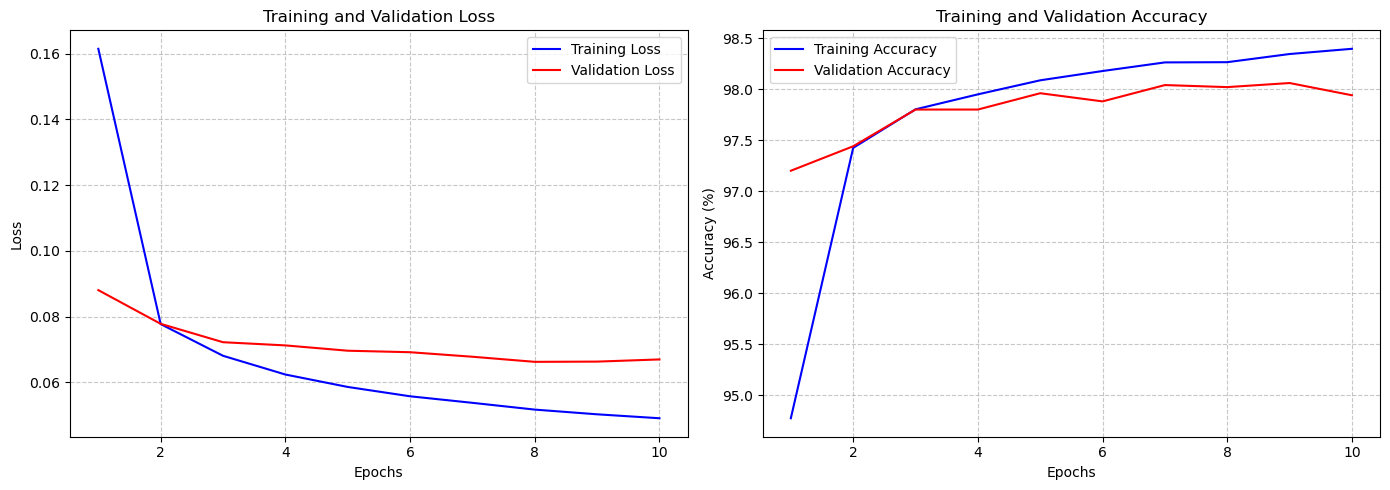

In [4]:
from mlflow.tracking import MlflowClient
import matplotlib.pyplot as plt

def plot_metrics_from_mlflow(run_id):
    client = MlflowClient()
    
    # Fetch metrics directly from the MLflow run
    train_loss = [m.value for m in client.get_metric_history(run_id, "train_loss")]
    val_loss = [m.value for m in client.get_metric_history(run_id, "val_loss")]
    train_acc = [m.value for m in client.get_metric_history(run_id, "train_accuracy")]
    val_acc = [m.value for m in client.get_metric_history(run_id, "val_accuracy")]
    
    epochs = range(1, len(train_loss) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Plot
    ax1.plot(epochs, train_loss, 'b-', label='Training Loss')
    ax1.plot(epochs, val_loss, 'r-', label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Accuracy Plot
    ax2.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    ax2.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Generate the plots using the run_id returned by your training function
plot_metrics_from_mlflow(run_id)

We can see very healthy curves. In this case maybe 4/5 epochs might have been enough, since that is where the gap between the 2 curves starts to widen.

Since all of this looks very promising, lets run the final evaulation on the test data

## 2. Evaluating the model on the final test set

In [5]:
def evaluate_on_test_set(run_id):
    print("\n--- Running Final Evaluation on Test Set ---")
    model.eval()
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
    final_test_accuracy = 100 * test_correct / test_total
    
    # Log to the existing MLflow run
    with mlflow.start_run(run_id=run_id):
        mlflow.log_metric("final_test_accuracy", final_test_accuracy)
        
    print(f"Final Test Accuracy: {final_test_accuracy:.2f}%")

# Execute the test evaluation
evaluate_on_test_set(run_id)


--- Running Final Evaluation on Test Set ---
Final Test Accuracy: 97.56%


### 3. Results comparison

As we can see the final test accuracy is `97.56%`. I will take that as a successful reproduction of what the paper claimed.

Results:
- DINOv2 paper claimed: `97.7%` test accuracy
- We got: `97.56%` test accuracy

Our reproduction achieved an accuracy of `97.56%`, which is just `0.14` percentage points below the paper's reported baseline of `97.7%`.

$$Percentage\ Error = \frac{|Actual - Expected|}{Expected} \times 100$$

$$0.143\% = \frac{|97.56 - 97.7|}{97.7} \times 100$$

We go `1,4` promille drift, which is insignificant and within the expected error.

### 4. Extension ideas

1. I would end experimentearlier at 5 epochs, to see if it would produce a better result
2. If I had more time/compute I would test on bigger datasets that are more meaningful. Like iNat2018 (iNaturalist 2018)

Dataset Composition:
- Species: Contains 8,142 species from across the natural world.
- Images: Includes 437,513 training images and 24,426 validation images.
- Categories: Covers various taxonomic groups, including plants, insects, birds, mammals, and reptiles.

<img src="Images/future_work.png" width=800>

I would try to reproduce that 81.6% accuracy of the biggest model. Just for fun :)